In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 40

In [4]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [7]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [8]:
cent_sfrs1 = subhalos["SubhaloSFR"][cent_mask_all]

In [9]:
cent_flag1 = subhalos["SubhaloFlag"][cent_mask_all]

In [10]:
cent_sfrs = np.zeros(len(halos["GroupFirstSub"]))
cent_sfrs[(halos["GroupFirstSub"]>-1)] = cent_sfrs1
#cent_sfrs[(halos["GroupFirstSub"]>-1)][cent_flag1 == 0] = 0
#cent_sfrs = np.log10(cent_sfrs)

In [11]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [12]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [13]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [14]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [15]:
sum_sfrs = np.zeros(len(halos["GroupFirstSub"]))
sum_sfrs[unique_ids] = sum_sfrs1
#sum_sfrs = np.log10(sum_sfrs)

In [16]:
mvir = np.log10(halos["Group_M_TopHat200"])+10

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [17]:
group_sfrs = halos["GroupSFR"]

In [18]:
group_bh = halos["GroupBHMass"]

In [19]:
cent_bh = np.zeros(len(halos["GroupFirstSub"]))
cent_bh[(halos["GroupFirstSub"]>-1)] = subhalos["SubhaloBHMass"][cent_mask_all]
#cent_sfrs[(halos["GroupFirstSub"]>-1)][cent_flag1 == 0] = 0
#cent_sfrs = np.log10(cent_sfrs)

In [24]:
cent_frac = cent_sfrs/group_sfrs

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [25]:
cent_frac = cent_sfrs/(cent_sfrs+sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [21]:
dlogM = 0.1
mhalo_bins = np.arange(10,14.5, dlogM)

In [22]:
def get_percentiles(data):
    median_list = []
    percentiles = [25, 50, 75]
    nbins = len(mhalo_bins)
    percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros(nbins, dtype=float)
    for i, m in enumerate(mhalo_bins):
        bin_mask = (mvir > m) & (mvir < m+dlogM)
        cfrac = data[bin_mask]
        median = np.nanmedian(cfrac)

        median_list.append(median)

        for ip, percentile in enumerate(percentiles):
            percentile_arr[ip][i] = np.nanpercentile(cfrac, q=percentile)

        bin_cents[i] = np.median(mvir[bin_mask])
    return percentile_arr

In [26]:
frac_percent = get_percentiles(cent_frac)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype.type(ret / rcount)


In [142]:
bh_percent = get_percentiles(np.log10(group_bh*1e10))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encoun

In [27]:
bh_percent_cent = get_percentiles(np.log10(cent_bh*1e10))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encoun

In [28]:
def get_frac(data):
    median_list = []
    percentiles = [25, 50, 75]
    nbins = len(mhalo_bins)
    percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros(nbins, dtype=float)
    for i, m in enumerate(mhalo_bins):
        bin_mask = (mvir > m) & (mvir < m+dlogM)
        cfrac = np.log10(data[bin_mask]*1e10)
        
        mask1 = cfrac > 8
        median = np.sum(mask1)/np.sum(bin_mask)

        median_list.append(median)

        for ip, percentile in enumerate(percentiles):
            percentile_arr[ip][i] = np.nanpercentile(cfrac, q=percentile)

        bin_cents[i] = np.median(mvir[bin_mask])
    return median_list

In [29]:
bh_frac = get_frac(group_bh)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in log10
  if __name__ == '__main__':
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in long_scalars
  if sys.path[0] == '':
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype

In [30]:
bh_frac_cent = get_frac(cent_bh)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in log10
  if __name__ == '__main__':
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in long_scalars
  if sys.path[0] == '':
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype

In [31]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

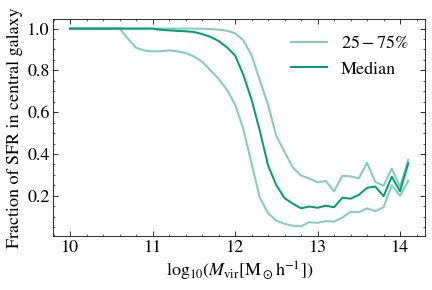

In [147]:
for i, p in enumerate(frac_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    plt.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])
    
plt.legend(["$25-75 \%$", "Median"])

plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.ylabel("Fraction of SFR in central galaxy")
ax = plt.gca()

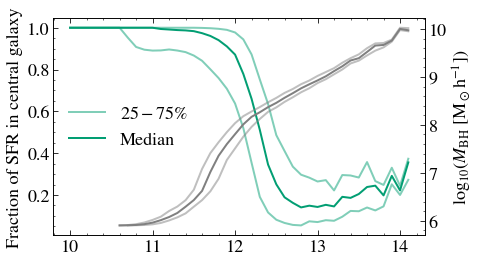

In [159]:
fig, ax1 = plt.subplots()
for i, p in enumerate(frac_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    ax1.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])
plt.legend(["$25-75 \%$", "Median"], loc="center left")
ax2 = ax1.twinx()
for i, p in enumerate(bh_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    ax2.plot(mhalo_bins, (p), alpha=alpha, color="grey")



plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
ax1.set_ylabel("Fraction of SFR in central galaxy")

ax2.set_ylabel(r"$\rm log_{10} $($M_{\mathrm{BH}}$ $\rm[M_\odot h^{-1}$])")
ax = plt.gca()
#ax.annotate("SubhaloFlag=1", (0.1,0.5), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/halo_sfr_frac.pdf", format="pdf", bbox_inches="tight")

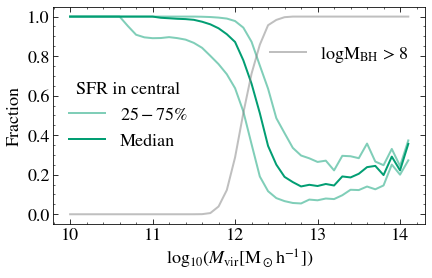

In [209]:
fig, ax1 = plt.subplots()
for i, p in enumerate(frac_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    ax1.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])
leg = ax1.legend(["$25-75 \%$", "Median"], loc="center left", title="SFR in central")
ax1.add_artist(leg)
# for i, p in enumerate(bh_frac):
#     if i == 1:
#         alpha = 1
#         label = "Median"
#     else:
#         alpha = 0.5
#         label="25th-75th percentile"
#     ax2.plot(mhalo_bins, (p), alpha=alpha, color="grey")
ax1.plot(mhalo_bins, bh_frac, alpha=alpha, color="grey", label = "logM$_{\mathrm{BH}}$ > 8" )
plt.legend(loc="upper right", bbox_to_anchor=(1,0.9))

plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
ax1.set_ylabel("Fraction")

#ax2.set_ylabel(r"Fraction with $\rm log_{10} $$M_{\mathrm{BH}}$ > 8")
#ax = plt.gca()
#ax.annotate("SubhaloFlag=1", (0.1,0.5), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/halo_sfr_frac_w_bh.pdf", format="pdf", bbox_inches="tight")

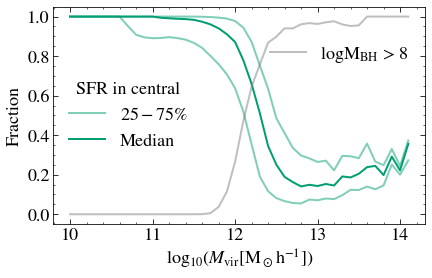

In [36]:
fig, ax1 = plt.subplots()
for i, p in enumerate(frac_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    ax1.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])
leg = ax1.legend(["$25-75 \%$", "Median"], loc="center left", title="SFR in central")
ax1.add_artist(leg)
# for i, p in enumerate(bh_frac):
#     if i == 1:
#         alpha = 1
#         label = "Median"
#     else:
#         alpha = 0.5
#         label="25th-75th percentile"
#     ax2.plot(mhalo_bins, (p), alpha=alpha, color="grey")
#ax1.plot(mhalo_bins, bh_frac, alpha=alpha, color="grey", label = "logM$_{\mathrm{BH}}$ > 8" )
ax1.plot(mhalo_bins, bh_frac_cent, alpha=alpha, color="grey", label = "logM$_{\mathrm{BH}}$ > 8" )

plt.legend(loc="upper right", bbox_to_anchor=(1,0.9))

plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
ax1.set_ylabel("Fraction")

#ax2.set_ylabel(r"Fraction with $\rm log_{10} $$M_{\mathrm{BH}}$ > 8")
#ax = plt.gca()
#ax.annotate("SubhaloFlag=1", (0.1,0.5), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/halo_sfr_frac_w_bh_cent.pdf", format="pdf", bbox_inches="tight")

In [ ]:
with $\rm log_{10} $$M_{\mathrm{BH}}$ > 8"